# MGIP MGB analysis

## Functions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.utils import concordance_index
from lifelines.statistics import multivariate_logrank_test, pairwise_logrank_test
import warnings
warnings.filterwarnings('ignore')

mpl.rcParams.update(mpl.rcParamsDefault)

sns.reset_orig()

import matplotlib.patheffects as pe

#################################################################################### Association analysis
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

def run_logit_with_units_and_refs(
    df,
    outcome: str,
    continuous_units: dict,     # {"Age": 10, "BMI": 5}
    categorical_refs: dict,     # {"Sex": "F", "Race": "White", "group": "Negative"}
    drop_na=True,
    print_counts=True,
    compute_auc=True
):
    import numpy as np
    import pandas as pd
    import statsmodels.formula.api as smf
    from sklearn.metrics import roc_auc_score

    data = df.copy()
    data[outcome] = pd.to_numeric(data[outcome], errors='coerce')

    # 1) continuous scaling(per unit)
    cont_terms_formula = []
    cont_terms_data = []
    pretty_cont_labels = {}
    for var, unit in continuous_units.items():
        data[var] = pd.to_numeric(data[var], errors='coerce')
        scaled = f"{var}_per_{unit}"
        data[scaled] = data[var] / float(unit)
        cont_terms_formula.append(f'Q("{scaled}")')
        cont_terms_data.append(scaled)
        pretty_cont_labels[scaled] = f"{var} (per {unit})"

    # 2) categorical + set reference
    cat_terms = []
    for var, ref in categorical_refs.items():
        data[var] = data[var].astype('category')
        if ref not in list(data[var].cat.categories):
            raise ValueError(f"[{var}] no ref '{ref}'. current: {list(data[var].cat.categories)}")
        cats = [ref] + [c for c in data[var].cat.categories if c != ref]
        data[var] = data[var].cat.set_categories(cats, ordered=True)
        cat_terms.append(f'C(Q("{var}"), Treatment(reference="{ref}"))')

    # 3) formula
    rhs_terms = cont_terms_formula + cat_terms
    if not rhs_terms:
        raise ValueError("No variables. fill out continuous_units or categorical_refs")
    formula = f"{outcome} ~ " + " + ".join(rhs_terms)

    # 4) remove nan
    needed_cols = [outcome] + cont_terms_data + list(categorical_refs.keys())
    data_model = data[needed_cols].dropna(axis=0) if drop_na else data.copy()

    # outcome sanity check
    if data_model.empty:
        raise ValueError("No rows left after NA filtering.")
    if data_model[outcome].nunique() < 2:
        raise ValueError(f"Outcome '{outcome}' has fewer than 2 classes after filtering.")

    # 4-1) print event counts
    total_n = len(data_model)
    total_events = int(data_model[outcome].sum())
    total_nonevents = int((data_model[outcome] == 0).sum())

    if print_counts:
        print(f"Total N used: {total_n}")
        print(f"Total events: {total_events}")
        print(f"Total non-events: {total_nonevents}")
        print(f"Event rate: {total_events / total_n:.4f}")

        if 'group' in data_model.columns:
            group_counts = (
                data_model
                .groupby('group', dropna=False)[outcome]
                .agg(
                    N='count',
                    Events='sum',
                    Non_events=lambda x: (x == 0).sum(),
                    Event_rate='mean'
                )
                .reset_index()
            )
            print("\nEvent counts by group:")
            display(group_counts)

    # 5) fit
    model = smf.logit(formula=formula, data=data_model).fit(disp=0)

    # 5-1) predicted probabilities + AUC
    auc = np.nan
    if compute_auc:
        pred_prob = model.predict(data_model)
        try:
            auc = roc_auc_score(data_model[outcome], pred_prob)
            print(f"AUC: {auc:.4f}")
        except Exception as e:
            print(f"[WARNING] Failed to compute AUC: {e}")
            pred_prob = None
    else:
        pred_prob = None

    # 6) result table (OR/CI/p)
    summ = model.summary2().tables[1].copy()
    summ['OR'] = np.exp(summ['Coef.'])
    summ['L_CI'] = np.exp(summ['[0.025'])
    summ['U_CI'] = np.exp(summ['0.975]'])
    summ.rename(columns={'P>|z|': 'p_value'}, inplace=True)

    # 7) labelling
    pretty_index = []
    meta = {}
    for idx in summ.index:
        idx_key = idx
        if idx.startswith('Q("') and idx.endswith('")'):
            idx_key = idx[3:-2]

        if idx_key in pretty_cont_labels:
            label = pretty_cont_labels[idx_key]
            pretty_index.append(label)
            meta[label] = {'type': 'cont'}

        elif idx.startswith("C("):
            var_raw = idx.split("(")[2].split(",")[0]

            if var_raw.startswith('"') and var_raw.endswith('")'):
                var = var_raw[1:-2]
            else:
                var = var_raw

            level = idx.split("]")[0].split("[T.")[-1]
            ref = categorical_refs[var]
            label = f"{var}: {level} (ref={ref})"
            pretty_index.append(label)
            meta[label] = {'type': 'cat', 'var': var, 'level': level, 'ref': ref}

        else:
            pretty_index.append(idx)
            meta[idx] = {'type': 'other'}

    summ.index = pretty_index
    summ = summ[~summ.index.str.contains('const', case=False, regex=False)]

    # 8) N_used / N_used_ref
    N_total = len(data_model)
    N_used_list = []
    N_used_ref_list = []

    for lbl in summ.index:
        info = meta.get(lbl, {'type': 'other'})
        if info['type'] == 'cont':
            N_used_list.append(N_total)
            N_used_ref_list.append(np.nan)

        elif info['type'] == 'cat':
            var, level, ref = info['var'], info['level'], info['ref']
            n_ref = int((data_model[var] == ref).sum())
            n_cmp = int((data_model[var] == level).sum())
            N_used_ref_list.append(n_ref)
            N_used_list.append(n_cmp)

        else:
            N_used_list.append(N_total)
            N_used_ref_list.append(np.nan)

    # 9) final table
    result = summ[['OR', 'L_CI', 'U_CI', 'p_value']].copy()
    result.insert(0, 'N_used_ref', N_used_ref_list)
    result.insert(1, 'N_used', N_used_list)
    result['OR (95% CI)'] = result.apply(
        lambda r: f"{r['OR']:.2f} ({r['L_CI']:.2f}, {r['U_CI']:.2f})", axis=1
    )
    result['p_value'] = result['p_value'].apply(
        lambda x: '{:.2e}'.format(x) if pd.notnull(x) else x
    )

    return {
        'model': model,
        'formula': formula,
        'N_total': N_total,
        'N_events': total_events,
        'N_non_events': total_nonevents,
        'AUC': auc,
        'pred_prob': pred_prob,
        'group_event_counts': group_counts if ('group' in data_model.columns and print_counts) else None,
        'table': result
    }

import numpy as np
import matplotlib.pyplot as plt

def filter_res_table(res, include_cont=None, include_cat=None, rename_dict=None):
    """
    res: run_logit_with_units_and_refs() return dict
    include_cont: list of cont: e.g. ['Age']
    include_cat:  list of cat -> include 'comparing level' dict. e.g. {'Sex':['M'], 'Race':['Black']}
    """
    tbl = res['table'].copy()
    if include_cont is None and include_cat is None:
        return tbl

    mask = np.zeros(len(tbl), dtype=bool)
    idx_list = tbl.index.tolist()

    tbl = tbl.rename(index=rename_dict)
    
    for i, label in enumerate(idx_list):
        # cont label: "Age (per ## unit increase)"
        if ' (per ' in label and ': ' not in label:
            base = label.split(' (per ')[0]  # 'Age'
            if include_cont and base in include_cont:
                mask[i] = True
            continue

        # cat label: "Sex: Male (ref=Female)"
        if ': ' in label and ' (ref=' in label:
            var = label.split(': ', 1)[0]                                  # 'Sex'
            level = label.split(': ', 1)[1].split(' (ref=')[0]             # 'Male'
            if include_cat and var in include_cat and level in include_cat[var]:
                mask[i] = True
            continue

    filtered = tbl[mask]
    if filtered.empty:
        raise ValueError("No rows remaining after filteration. Check 'include_cont/include_cat'")
    return filtered

def plot_forest_from_res_filtered(res, include_cont=None, include_cat=None, xlog=True, 
                                  rename_dict=None, save=None, order=None, risk=None):
    """
    OR
    res: run_logit_with_units_and_refs() result
    include_cont: e.g. ['Age']
    include_cat:  e.g. {'Sex': ['M'], 'Race': ['Black']}

    HR
    Input table = already formatted 
    """
    if risk == 'OR':
        tbl = filter_res_table(res, include_cont=include_cont, include_cat=include_cat, rename_dict=rename_dict).copy()
    elif risk =='HR':
        tbl = res.copy()
        tbl = tbl.rename(index=rename_dict)

    if order is not None:
        existing_items_in_order = [item for item in order if item in tbl.index]
        tbl = tbl.reindex(existing_items_in_order)

    OR = tbl[risk].to_numpy()
    L  = tbl['L_CI'].to_numpy()
    U  = tbl['U_CI'].to_numpy()
    L = np.where(L <= 0, np.nan, L)
    U = np.where(U <= 0, np.nan, U)
    xerr = np.vstack([OR - L, U - OR])
    y = np.arange(len(tbl))

    # ── 1) sharey-> share same y-axis ──
    fig, (ax_plot, ax_text) = plt.subplots(
        nrows=1, ncols=2,
        figsize=(10, max(3.5, len(tbl)*0.6 + 1.2)),
        gridspec_kw={'width_ratios': [3, 2]},
        sharey=True                     # y-axis share
    )
    
    # left: errorbar
    ax_plot.errorbar(
        x=OR, y=y, xerr=np.vstack([OR - L, U - OR]),
        fmt='o', color='black', markersize=7, capsize=5, linestyle='None'
    )
    ax_plot.set_yticks(y)
    ax_plot.set_yticklabels(tbl.index, fontsize=12)

    ## remove axis lines
    for side in ['left', 'top', 'right']:
        ax_plot.spines[side].set_visible(False)

    # Xlimit
    xmin = np.nanmin(L)
    xmax = np.nanmax(U)
    if np.isfinite(xmin) and np.isfinite(xmax):
        if xlog:
            ax_plot.set_xscale('log')
            
            if xmin <= 0: 
                xmin = 0.1 # Set default value
            
            margin_factor = 1.5 
            left_lim = xmin / margin_factor
            right_lim = xmax * margin_factor
            
            ax_plot.set_xlim(left=left_lim, right=right_lim)

        else:
            margin = 0.15
            span = xmax - xmin
            
            if xmin >= 1.0:
                left_lim = 1.0 - span * 0.5
                if left_lim < 0:
                    left_lim = -0.2
            else:
                left_lim = xmin - margin * span
            
            right_lim = xmax + margin * span
            ax_plot.set_xlim(left=left_lim, right=right_lim)
    ax_plot.set_xlim(left=left_lim, right=right_lim)
    risk_dict = {"OR" : "Odds Ratio", "HR" : "Hazard Ratio"}
    ax_plot.set_xlabel(f"{risk_dict[risk]}")

    #1.0 line
    ax_plot.axvline(x=1, linestyle='--', color='grey', linewidth=1)
    
    ymin, ymax = -0.5, len(tbl) - 0.5
    ax_plot.set_ylim(ymin, ymax)
    ax_text.set_ylim(ymin, ymax + 1.0)   

    ax_plot.set_facecolor('none')  
    
    ax_text.axis('off')
    #x_positions = [0.00, 0.8, 1.8]
    x_positions = [0.00, 1.3, 3.3]
    
    header_y = y.max() + 0.7
    ax_text.text(x_positions[0], header_y, 'Number',    weight='bold', ha='left',  fontsize=12)
    ax_text.text(x_positions[1], header_y, f'{risk} (95% CI)', weight='bold', ha='left',  fontsize=12)
    ax_text.text(x_positions[2], header_y, 'p-value',     weight='bold', ha='right', fontsize=12)
    
    for i, (idx, row) in enumerate(tbl.iterrows()):
        yy = y[i] 
        if np.isnan(row.get('N_used_ref', np.nan)):
            n_text = f"N = {int(row['N_used']):,}"
        else:
            n_text = f"N = {int(row['N_used']):,}\nRef. = {int(row['N_used_ref']):,}"
    
        or_ci_text = f"{row[risk]:.2f} ({row['L_CI']:.2f}, {row['U_CI']:.2f})"
        p_text = row['p_value']
    
        ax_text.text(x_positions[0], yy, f"{n_text}", va='center', ha='left', fontsize=11) #f"{idx} {n_text}"
        ax_text.text(x_positions[1], yy, or_ci_text,        va='center', ha='left', fontsize=11)
        ax_text.text(x_positions[2], yy, p_text,            va='center', ha='right', fontsize=11)

    plt.subplots_adjust(
        left=0.35,   
        right=0.65,  
        wspace=0.15  
    )
    if save is not None:
        plt.savefig(save)
    plt.show()
    plt.close('all')


### Correlation function
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

def plot_corr_ancestry_totalIG(df, hue_col=None,
                              x_col=None,
                              y_col=None,
                              age_col='Age',
                              fh_col='hema_fh'):
    # 1) data prep
    cols = [x_col, y_col, age_col, fh_col] + ([hue_col] if hue_col else [])
    d = df[cols].copy()
    d = d.dropna(subset=[x_col, y_col, age_col, fh_col])

    # 2) hema_fh
    #    (e.g. 'Yes'/'No'-> cat)
    is_fh_categorical = d[fh_col].dtype == 'object' or str(d[fh_col].dtype).startswith('category')

    if is_fh_categorical:
        formula = f"{y_col} ~ {x_col} + {age_col} + C({fh_col})"
    else:
        formula = f"{y_col} ~ {x_col} + {age_col} + {fh_col}"

    # 3) fit
    model = smf.ols(formula, data=d).fit()

    # 4) AFR slope & p-value
    beta = model.params.get(x_col, np.nan)
    pval = model.pvalues.get(x_col, np.nan)

    # 5) conditional regression 
    x_min, x_max = d[x_col].min(), d[x_col].max()
    X_line = np.linspace(x_min, x_max, 200)

    # Age: average
    age_mean = d[age_col].mean()

    # hema_fh: ‘No’ --> No, if not, mode
    if is_fh_categorical:
        fh_levels = d[fh_col].astype('category').cat.categories.tolist()
        if 'No' in fh_levels:
            fh_ref = 'No'
        else:
            fh_ref = d[fh_col].mode().iloc[0]
        pred_df = pd.DataFrame({x_col: X_line, age_col: age_mean, fh_col: fh_ref})
    else:
        fh_mean = d[fh_col].mean()
        pred_df = pd.DataFrame({x_col: X_line, age_col: age_mean, fh_col: fh_mean})

    y_pred = model.predict(pred_df)

    plt.figure(figsize=(6,5))
    if hue_col:
        sns.scatterplot(data=d, x=x_col, y=y_col, hue=hue_col, alpha=0.7, s=40)
    else:
        sns.scatterplot(data=d, x=x_col, y=y_col, color='tab:blue', alpha=0.7, s=40)

    plt.plot(X_line, y_pred, linewidth=2)  

    # 7) annotate: beta, pvalue
    annot = f"slope (adj) = {beta**2:.4g}\np = {pval:.2e}"
    x_text = x_min + 0.02*(x_max - x_min)
    y_min, y_max = d[y_col].min(), d[y_col].max()
    y_text = y_max - 0.1*(y_max - y_min)
    plt.text(x_text, y_text, annot, fontsize=11,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()
    plt.close('all')

    print(model.summary())
    return model
####################################################################################


def draw_risk_table_manual(risk_df, ax_table, color_map=None, fontsize=None):
    """
    risk_df:
        index   = time points (e.g.: 0,1,2,... years)
        columns = group names (in order)
    """
    color_map = color_map or {}

    # 1. style
    ax_table.set_frame_on(False)
    ax_table.grid(False)
    ax_table.set_xticks([])  
    ax_table.tick_params(axis='y', length=0)  

    n_groups = len(risk_df.columns)
    y_pos_list = np.arange(n_groups)

    ax_table.set_yticks(y_pos_list)
    ax_table.set_yticklabels([])
    # ax_table.set_yticklabels(risk_df.columns,
    #                          fontsize=17, #fixed
    #                          ha="right",
    #                          color='black')

    # 2. Text insert (Table)
    for j, group_name in enumerate(risk_df.columns[::-1]):
        y_pos = j
        color = color_map.get(group_name, 'black')

        # N at Risk 
        for time_point, n_at_risk in risk_df[group_name].dropna().items():
            ax_table.text(
                time_point,
                y_pos,
                f"{int(n_at_risk):,}",
                ha='center', va='center',
                fontsize=fontsize,
                color=color,
                path_effects=[
                    pe.Stroke(linewidth=1.5, foreground='white'),
                    pe.Normal()
                ]
            )

    ax_table.set_ylim(-0.5, n_groups - 0.5)


def plot_kaplan_meier(df, duration_col, event_col, group_col, 
                      y_label=None, group_order=None,
                      palette=None, overall_pval=False,
                      time_points=None, y_lim=None,
                      save=None):
    
    if group_order is None:
        group_order = sorted(df[group_col].dropna().unique().tolist())
    palette = palette or {}

    fig, axes = plt.subplots(
        nrows=2, ncols=1, figsize=(10, 8),
        sharex=True,
        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05}
    )
    ax_plot, ax_table = axes

    kmf = KaplanMeierFitter()
    
    risk_table_data = []
    #risk_table_data = {}

    # --- 1. KM fitting and draw per group (group_order) ---
    for group_name in group_order:
        group_df = df[df[group_col] == group_name]
        if group_df.empty:
            continue

        T_g = group_df[duration_col]
        E_g = group_df[event_col]

        color = palette.get(group_name)

        label = f"{group_name} (n={len(group_df):,})"
        kmf.fit(T_g, event_observed=E_g, label=label)

        line_thickness = 3
        kmf.plot_survival_function(
            ax=ax_plot, 
            ci_show=True, 
            color=color,
            linewidth=line_thickness,
        )

        line_artist = ax_plot.get_lines()[-1]
        
        # 3. Path Effects 
        line_artist.set_path_effects([
            pe.Stroke(linewidth=line_thickness + 1, foreground='black'), 
            pe.Normal() 
        ])

        #print(kmf.event_table[['at_risk', 'observed', 'censored']].head(20))
        risk_counts = kmf.event_table['at_risk'].rename(group_name)
        risk_table_data.append(risk_counts)
        
    # --- 2. year timepoint  ---
    if time_points is None:
        max_time = df[duration_col].max()
        time_points = np.arange(0, np.floor(max_time) + 0.1, 1.0)
    else:
        time_points = np.asarray(time_points, dtype=float)

    # --- 3. Risk Table dataframe  ---
    risk_table_df = pd.concat(risk_table_data, axis=1)
    risk_table_df = risk_table_df.sort_index()
    ## Forward fill
    risk_table_df = risk_table_df.ffill()
    risk_table_year = risk_table_df.reindex(time_points, method='ffill')

    # risk table 
    draw_risk_table_manual(risk_table_year, ax_table, palette, fontsize=12)

    # --- 4. Log-rank test (total / pairwise) ---
    groups_all = df[group_col]
    T_all = df[duration_col]
    E_all = df[event_col]

    logrank_results_overall = multivariate_logrank_test(T_all, groups_all, E_all)
    p_value_overall = logrank_results_overall.p_value
    print("--- Overall P-value ---")
    print(p_value_overall)
    print("---------------------------------------")

    logrank_results_pairwise = pairwise_logrank_test(T_all, groups_all, E_all)
    print("--- Pairwise Log-Rank Test Results ---")
    print(logrank_results_pairwise.summary)
    print("---------------------------------------")

    # --- 5. plot style ---
    ax_plot.set_xlabel('Time (Years)', fontsize=20)
    ax_plot.set_ylabel(y_label, fontsize=20)
    #ax_plot.tick_params(axis='x', labelsize=20)

    ax_plot.xaxis.set_label_position('bottom')
    ax_plot.xaxis.set_ticks_position('bottom')
    ax_plot.tick_params(axis='x', which='both', labelbottom=True, labelsize=20)
    ax_table.tick_params(axis='x', which='both', labelbottom=False, length=0)
    ax_plot.tick_params(axis='y', labelsize=20)
    ax_plot.set_xticks(time_points)             
    ax_plot.set_xlim(time_points.min(), time_points.max())
    if y_lim:
        ax_plot.set_ylim(y_lim[0], y_lim[-1])

    if overall_pval:
        ax_plot.text(
            0.50, 0.90,
            f"Overall Log-Rank p = {p_value_overall:.3e}",
            transform=ax_plot.transAxes,
            fontsize=17,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.5)
        )

    ax_plot.grid(False)
    ax_plot.legend(
        loc='lower left',          
        #bbox_to_anchor=(1.02, 1.0), 
        fontsize=17
    )
    plt.tight_layout()
    if save:
        plt.savefig(save, bbox_inches='tight', dpi=300)
    plt.show()
    plt.close('all')

from lifelines import CoxPHFitter

def run_cox_analysis_and_format(df, duration_col, event_col, covariates, reference_group_dict=None, penalizer = None, model_QC=None):
    df_cph = df.copy()
    formula_parts = []
    
    if reference_group_dict:
        for col, ref_group in reference_group_dict.items():
            categories = [c for c in df_cph[col].unique() if c != ref_group and pd.notna(c)]
            for cat in categories:
                
                safe_cat_name = str(cat).replace(' ', '_') 
                dummy_col_name = f"{col}_{safe_cat_name}"
                
                df_cph[dummy_col_name] = (df_cph[col] == cat).astype(int)
                formula_parts.append(dummy_col_name)
    
    cont_vars = [c for c in covariates if c not in (reference_group_dict or {})]
    formula_parts.extend(cont_vars)
    
    if not formula_parts:
        print("Error: No covariates to test.")
        return pd.DataFrame()
    
    #cph = CoxPHFitter()
    cph = CoxPHFitter(penalizer=penalizer)
    
    analysis_cols = [duration_col, event_col] + formula_parts
    df_clean = df_cph[analysis_cols].dropna()

    
    ###### Model QC
    ## penalizer sensitivity
    pen_list = [0.0, 0.01, 0.05, 0.1, 0.5, 1.0]
    out = []
    
    for pen in pen_list:
        cph = CoxPHFitter(penalizer=pen)
        cph.fit(df_clean, duration_col=duration_col, event_col=event_col)
    
        s = cph.summary.copy()
        s = s.reset_index()  
        s = s.rename(columns={"index": "variable"}) 
        if "covariate" in s.columns:                 
            s = s.rename(columns={"covariate": "variable"})
    
        s["penalizer"] = pen
        out.append(s[["variable","penalizer","coef","exp(coef)","p"]])
    
    sens_df = pd.concat(out)

    if model_QC:
        plt.figure(figsize=(7,5))
        
        sns.lineplot(
            data=sens_df,
            x="penalizer",
            y="exp(coef)",
            hue="variable",
            marker="o"
        )
        plt.axhline(1.0, linestyle="--", color="gray", alpha=0.5)
        plt.xscale("log")  
        
        plt.xlabel("Penalizer (log scale)")
        plt.ylabel("Hazard Ratio (exp(coef))")
        plt.title("Cox Penalizer Sensitivity Analysis")
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

        ## PH check
        cph.check_assumptions(df_clean, p_value_threshold=0.05, show_plots=True)

    ## event rate
    E = int(df_clean[event_col].sum())
    N = len(df_clean)
    print("N=", N, "Events=", E, "Event rate=", E/N)

    cph.fit(df_clean, duration_col, event_col, formula=" + ".join(formula_parts))
    print("--- CoxPH Model Summary ---")
    #cph.print_summary()
    
    summary_df = cph.summary

    formatted_df = summary_df.rename(columns={
        'exp(coef)': 'HR', 
        'exp(coef) lower 95%': 'L_CI',
        'exp(coef) upper 95%': 'U_CI',
        'p': 'p_value'
    })
    
    #formatted_df['p_value'] = formatted_df['p_value'].apply(lambda p: f"{p:.2e}" if p < 0.01 else f"{p:.3f}")
    formatted_df['p_value'] = formatted_df['p_value'].apply(lambda p: f"{p:.3e}")
    
    formatted_df['N_used'] = len(df_clean)
    
    formatted_df['N_used_ref'] = np.nan 

    ###################### Model evaluation ############################3

    c_index = concordance_index(
        df_clean[duration_col], 
        -cph.predict_partial_hazard(df_clean), # Applying negative sign because higher partial hazard scores indicate higher risk of event occurrence
        df_clean[event_col]
    )
    
    print(f"**1. C-statistic (Concordance Index): {c_index:.4f}**")
    print("-" * 50)
    
    
    # 4. Critical Assumption Check: Proportional Hazards Assumption Test
    print("## 2. Proportional Hazards Assumption Test (Schoenfeld Residuals)")
    ph_results = cph.check_assumptions(df_clean, p_value_threshold=0.05, show_plots=False)
    
    # Displaying Test Results Table
    print("--- P-value Summary of Test Results (Schoenfeld Residuals Test Interpretation) ---")
    display(ph_results)

    #### Output
    return formatted_df


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import AalenJohansenFitter

def gray_test_cmprsk(time, status, group, failcode=1, cencode=0):
    import numpy as np
    import pandas as pd
    import rpy2.robjects as ro
    from rpy2.robjects.packages import importr
    from rpy2.robjects import pandas2ri
    from rpy2.robjects.conversion import localconverter
    from rpy2.robjects import default_converter

    cmprsk = importr("cmprsk")

    df_r = pd.DataFrame({
        "ftime": np.asarray(time, dtype=float),
        "fstatus": np.asarray(status, dtype=int),
        "group": pd.Series(group).astype(str).values
    }).dropna()

    with localconverter(default_converter + pandas2ri.converter):
        r_df = ro.conversion.py2rpy(df_r)

    ftime = r_df.rx2("ftime")
    fstatus = r_df.rx2("fstatus")
    group_factor = ro.r["as.factor"](r_df.rx2("group"))

    ci = cmprsk.cuminc(ftime=ftime, fstatus=fstatus, group=group_factor, cencode=cencode)

    def extract_p_value(ci_obj, target_failcode):
        """Extract Gray test p-value for a given cause (failcode) from ci$Tests."""
        try:
            tests = ci_obj.rx2("Tests")  # R matrix
            # row/col names
            rownames = list(map(str, list(ro.r["rownames"](tests))))
            colnames = list(map(str, list(tests.colnames)))

            # convert R matrix -> numpy 2D (IMPORTANT: reshape with Fortran order)
            nrow = int(ro.r["nrow"](tests)[0])
            ncol = int(ro.r["ncol"](tests)[0])
            mat = np.array(tests, dtype=float).reshape((nrow, ncol), order="F")

            target = str(target_failcode)
            if target not in rownames:
                # sometimes rownames like "1  " etc; normalize
                rn_norm = [r.strip() for r in rownames]
                if target in rn_norm:
                    row_idx = rn_norm.index(target)
                else:
                    return None
            else:
                row_idx = rownames.index(target)

            if "pv" in colnames:
                p = mat[row_idx, colnames.index("pv")]
            else:
                # fallback: last column is often p-value
                p = mat[row_idx, -1]

            if np.isnan(p):
                return None
            return float(p)
        except Exception as e:
            print(f"[extract_p_value] Error: {e}")
            return None

    overall_p = extract_p_value(ci, failcode)

    # pairwise
    uniq = sorted(df_r["group"].unique())
    pairwise_p = {}
    for i in range(len(uniq)):
        for j in range(i + 1, len(uniq)):
            g1, g2 = uniq[i], uniq[j]
            sub = df_r[df_r["group"].isin([g1, g2])].copy()

            with localconverter(default_converter + pandas2ri.converter):
                r_sub = ro.conversion.py2rpy(sub)

            ci_sub = cmprsk.cuminc(
                ftime=r_sub.rx2("ftime"),
                fstatus=r_sub.rx2("fstatus"),
                group=ro.r["as.factor"](r_sub.rx2("group")),
                cencode=cencode
            )
            pairwise_p[(g1, g2)] = extract_p_value(ci_sub, failcode)

    return {"overall_p": overall_p, "pairwise_p": pairwise_p}


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import AalenJohansenFitter

def _at_risk_counts(time, status, time_points):
    """
    time: array-like durations
    status: array-like status codes (0=censor, 1=event, 2+=competing)
    at risk at t := # subjects with time >= t (still under observation just before t)
    """
    t = np.asarray(time, dtype=float)
    # status not used for at-risk; only time matters
    out = []
    for tp in time_points:
        out.append(int(np.sum(t >= tp)))
    return np.asarray(out, dtype=int)

def plot_cif_aj_with_graytest(
    df, duration_col, status_col, group_col,
    event_of_interest=1,
    group_order=None,
    palette=None,
    ylim=(0, 0.1),
    figsize=(10,8),
    do_gray_test=True,
    time_points=None,
    overall_pval=True,
    return_cif_at=None,   
    save=None,
):
    """
    CIF (Aalen-Johansen) + Gray test + risk table.

    status_col codes:
      0 = censor
      1 = event_of_interest
      2/3/... = competing events
    """

    # --- 0) Clean ---
    cols = [duration_col, status_col, group_col]
    d = df[cols].dropna().copy()
    d[status_col] = pd.to_numeric(d[status_col], errors="coerce").fillna(0).astype(int)
    d[duration_col] = pd.to_numeric(d[duration_col], errors="coerce")
    d = d.dropna(subset=[duration_col])
    d = d[d[duration_col] >= 0].copy()
    d[group_col] = d[group_col].astype(str)

    if group_order is None:
        group_order = sorted(d[group_col].unique().tolist())
    palette = palette or {}

    # --- 1) time_points (year grid like KM) ---
    if time_points is None:
        max_time = float(np.nanmax(d[duration_col].values))
        time_points = np.arange(0, np.floor(max_time) + 0.1, 1.0)
    else:
        time_points = np.asarray(time_points, dtype=float)

    # --- 2) Layout: plot + table ---
    fig, axes = plt.subplots(
        nrows=2, ncols=1, figsize=figsize,
        sharex=True,
        #gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05}
        gridspec_kw={'height_ratios': [3.2, 1.3], 'hspace': 0.15}
    )
    ax_plot, ax_table = axes

    # collect risk table columns
    risk_cols = []

    cif_at_times = {}
    # --- 3) Fit/plot per group + compute at-risk counts ---
    group_n = {}
    
    for g in group_order:
        dg = d[d[group_col] == str(g)]
        if dg.empty:
            continue

        ajf = AalenJohansenFitter()

        T = dg[duration_col].values
        E = dg[status_col].values

        #label = f"{g} (n={len(dg):,})"
        #ajf.fit(T, E, event_of_interest=event_of_interest, label=label)
        ajf.fit(T, E, event_of_interest=event_of_interest, label=g)

        color = palette.get(g, None)
        ajf.plot(ax=ax_plot, color=color, linewidth=2.5)

        # at-risk for table
        ar = _at_risk_counts(T, E, time_points)
        risk_cols.append(pd.Series(ar, index=time_points, name=g))

        # number
        group_n[g] = len(dg)

        line_thickness = 3
        line_artist = ax_plot.get_lines()[-1]
        
        line_artist.set_path_effects([
            pe.Stroke(linewidth=line_thickness + 1, foreground='black'), 
            pe.Normal() 
        ])
        
        # cumlative incidecne at given years
        if return_cif_at is not None:
            query_times = np.atleast_1d(return_cif_at).astype(float)

            cif_df = ajf.cumulative_density_.copy()
            cif_series = cif_df.iloc[:, 0]   # first/only CIF column

            # step function evaluation: use last observed value <= t
            cif_vals = (
                cif_series.reindex(
                    cif_series.index.union(query_times)
                )
                .sort_index()
                .ffill()
                .reindex(query_times)
                .fillna(0.0)
            )

            cif_at_times[g] = dict(zip(query_times, cif_vals.astype(float)))

    # --- 4) Draw risk table (reuse your function) ---
    if len(risk_cols) > 0:
        risk_table_year = pd.concat(risk_cols, axis=1)
        risk_table_year.index.name = "time"
        # in case time_points not strictly increasing or missing
        risk_table_year = risk_table_year.loc[time_points]

        # You already have this function in your notebook.
        draw_risk_table_manual(risk_table_year, ax_table, palette, fontsize=12)
    else:
        ax_table.axis("off")

    # --- 5) Gray test ---
    overall_p, pairwise_p = None, None
    if do_gray_test:
        gray_res = gray_test_cmprsk(
            time=d[duration_col].values,
            status=d[status_col].values,
            group=d[group_col].astype(str),
            failcode=event_of_interest,
            cencode=0
        )
        overall_p = gray_res["overall_p"]
        pairwise_p = gray_res["pairwise_p"]
        print("Gray test overall:", overall_p)
        print("Gray test pairwise:", pairwise_p)

    # --- 6) Styling ---
    ax_plot.set_ylabel(f"Cumulative Incidence", fontsize=20)
    ax_plot.set_xlabel("Time (Years)", fontsize=20)

    ax_plot.set_xlim(time_points.min(), time_points.max())
    ax_plot.set_xticks(time_points)
    ax_plot.set_ylim(*ylim)

    ax_plot.tick_params(axis='x', which='both', labelbottom=True, labelsize=20)
    ax_plot.tick_params(axis='y', labelsize=20)

    # Table axis: hide x tick labels
    ax_table.tick_params(axis='x', which='both', labelbottom=False, length=0)

    ax_plot.grid(False)

    # Show overall p-value on plot
    if overall_pval and do_gray_test and overall_p is not None:
        ax_plot.text(
            0.60, 0.90,
            f"Overall Gray p = {overall_p:.3e}" if isinstance(overall_p, (float, np.floating)) else f"Overall Gray p = {overall_p}",
            transform=ax_plot.transAxes,
            fontsize=14,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.5)
        )

    handles, labels = ax_plot.get_legend_handles_labels()
    
    label_to_handle = dict(zip(labels, handles))
    
    ordered_handles = []
    ordered_labels = []
    
    for g in group_order:
        if g in label_to_handle:
            h = label_to_handle[g]
            n = group_n.get(g, 0)
            ordered_handles.append(h)
            ordered_labels.append(f"{g} (n={n:,})")
    
    ax_plot.legend(
        ordered_handles,
        ordered_labels,
        loc='upper left',
        fontsize=14
    )
    #plt.tight_layout()
    
    if save:
        plt.savefig(save, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close('all')

    return {
        "overall_gray_p": overall_p,
        "pairwise_gray_p": pairwise_p,
        "risk_table": (risk_table_year if len(risk_cols) > 0 else None),
        "cif_at_times": cif_at_times 

    }


########### Visualization functions
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from statannotations.Annotator import Annotator

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from itertools import combinations
from statannotations.Annotator import Annotator
import warnings; warnings.filterwarnings('ignore')
from statsmodels.stats.multitest import multipletests

def cohen_d(data1, data2):
    n1, n2 = len(data1), len(data2)
    
    if n1 < 2 or n2 < 2:
        return np.nan

    mean1, mean2 = np.mean(data1), np.mean(data2)
    std1, std2 = np.std(data1, ddof=1), np.std(data2, ddof=1)
    
    s_pooled = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
    
    if s_pooled == 0:
        return 0.0

    d = (mean1 - mean2) / s_pooled
    return abs(d) 

def plot_violin_with_stats(df, x_col, y_col, order=None, y_label=None, palette=None, save=None):
    # 0. Data preparation (drop NA)
    plot_data = df[[x_col, y_col]].dropna()
    
    # Group order
    plot_data = plot_data[plot_data[x_col].isin(order)]
    
    # 1. Create groups
    pairs = list(combinations(order, 2))
    
    if not pairs:
        print(f"'{x_col}' has < 2 groups")
        return

    # 2. Mann-Whitney U test -> FDR -> p-value formatting, and Cohen's d
    stats_results = {} # (p_raw, cohen_d) 
    raw_p_values = []  # for FDR 
    
    for group1, group2 in pairs:
        data1 = plot_data[plot_data[x_col] == group1][y_col]
        data2 = plot_data[plot_data[x_col] == group2][y_col]
        
        if len(data1) < 2 or len(data2) < 2:
            stats_results[(group1, group2)] = (np.nan, np.nan)
            raw_p_values.append(np.nan)
            continue
            
        # Mann-Whitney U test
        stat, p_val = mannwhitneyu(data1, data2, alternative='two-sided')
        
        # Cohen's d
        d_val = cohen_d(data1, data2)
        
        stats_results[(group1, group2)] = (p_val, d_val)
        raw_p_values.append(p_val)

    raw_pvals_array = np.array(raw_p_values)
    mask = pd.notna(raw_pvals_array) 
    
    p_val_adj = np.full_like(raw_pvals_array, np.nan) 
    
    if np.any(mask):
        reject, p_val_adj_masked, _, _ = multipletests(
            raw_pvals_array[mask], 
            alpha=0.05, 
            method='fdr_bh'
        )
        p_val_adj[mask] = p_val_adj_masked
        
    custom_p_values = []
    for i, (group1, group2) in enumerate(pairs):
        p_raw, d_val = stats_results[(group1, group2)]
        p_adj = p_val_adj[i]
        
        if pd.isna(p_adj):
            formatted_p = "n.s."
        else:
            formatted_p = f"p_adj={p_adj:.2e}" 
            
        # Cohen's d 
        if pd.isna(d_val):
            formatted_d = "d=n/a"
        else:
            formatted_d = f"d={d_val:.2f}"
            
        final_string = f"{formatted_p}\n{formatted_d}"
        custom_p_values.append(final_string)

    # 3. Create plot 
    fig, (ax_annot, ax_plot) = plt.subplots(
        nrows=2, 
        ncols=1, 
        figsize=(12, 10), 
        sharex=True,      
        gridspec_kw={'height_ratios': [1, 3]} 
    )
    
    plt.subplots_adjust(hspace=0)

    # 4. Draw MAIN PLOT on the BOTTOM axis (ax_plot)
    
    # Outer Violinplot
    sns.violinplot(
        data=plot_data, x=x_col, y=y_col, order=order,
        alpha=1, linewidth=3, 
        inner=None,
        palette=palette,
        ax=ax_plot,
    )
    
    # Inner Boxplot
    sns.boxplot(
        data=plot_data, x=x_col, y=y_col, order=order,
        width=0.1, 
        boxprops={'edgecolor': 'black', 'linewidth' : 3, 'facecolor': 'white'},
        whiskerprops={'linewidth': 3},  
        medianprops={'linewidth': 3},
        showfliers=False, 
        ax=ax_plot 
    )

    # # Strip
    # sns.stripplot(
    #     data=plot_data, x=x_col, y=y_col, order=order,
    #     color='black', jitter=True, size=2.5, alpha=0.6,
    #     ax=ax_plot
    # )
    
    max_val = plot_data[y_col].max()
    #ax_plot.set_ylim(0, max_val * 1.1) 
    ax_plot.set_xlabel("")
    ax_plot.set_ylabel(y_label, fontsize=20)
    ax_plot.spines[['top', 'right']].set_visible(False) 

    counts_map = plot_data[x_col].value_counts()
    
    xticklabels = [
        f"{group}\n(N = {counts_map.get(group, 0):,})" for group in order
    ]
    ax_plot.tick_params(axis='y', labelsize=20)
    ax_plot.set_xticklabels(xticklabels, fontsize=20)

    # 5. Draw ANNOTATIONS on the TOP axis (ax_annot)
    if custom_p_values:
        annotator = Annotator(
            ax_annot, 
            pairs,
            data=plot_data,
            x=x_col,
            y=y_col,
            order=order,
            linewidth=1.5 
        )
        annotator.set_custom_annotations(custom_p_values)
        annotator.configure(
            text_format="simple",
            fontsize=17,          
            line_height=0.7,      
        )
        annotator.annotate()
        
    #ax_annot.set_title(f"Distribution of '{y_col}' by '{x_col}'", fontsize=16)
    ax_annot.set_ylabel("") 
    ax_annot.set_yticks([]) 
    ax_annot.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

    plt.tight_layout()
    if save is not None:
        plt.savefig(save)
    plt.show()
    plt.close('all')

def plot_hist_kde_by_group(df, x_col, y_col, bin_width=10):
    
    # 0. Data preparation (remove NA)
    plot_data = df[[x_col, y_col]].dropna()
    
    plot_data[x_col] = plot_data[x_col].astype(str)

    order = sorted(plot_data[x_col].unique())

    if len(order) < 1:
        print("No data to plot.")
        return

    # 1. Binning 
    min_val = np.floor(plot_data[y_col].min() / bin_width) * bin_width
    max_val = np.ceil(plot_data[y_col].max() / bin_width) * bin_width
    bins = np.arange(min_val, max_val + bin_width, bin_width)

    # 2. Plot
    plt.figure(figsize=(12, 7))

    ax = sns.histplot(
        data=plot_data,
        x=y_col,
        hue=x_col,
        hue_order=order,
        kde=True,
        bins=bins,
        stat="density",
        common_norm=False,
        element="step",
        linewidth=2
    )

    ax.set_xlabel(y_col, fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    
    try:
        ax.get_legend().set_title(x_col)
    except AttributeError:
        print("Legend could not be created.") 
        
    plt.tight_layout()
    plt.show()
    plt.close('all')


def get_result_reg(result):
    summary_df = result.summary2().tables[1].copy()
    
    summary_df["OR"] = np.exp(summary_df["Coef."])
    summary_df["CI_lower_OR"] = np.exp(summary_df["[0.025"])
    summary_df["CI_upper_OR"] = np.exp(summary_df["0.975]"])
    
    summary_df = summary_df[[
        "Coef.", "OR",
        "Std.Err.", "z", "P>|z|",
        "CI_lower_OR", "CI_upper_OR"
    ]]
    
    N = len(y)
    E = int(y.sum())
    event_rate = E / N
    
    model_info = pd.DataFrame({
        "Model": ['Interaction Logit'],
        "N": [N],
        "Events": [E],
        "Event rate": [event_rate],
        "LogLik": [res.llf],
        "LLR p-value": [res.llr_pvalue],
        "Pseudo R2": [res.prsquared]
    })
    display(model_info)
    display(summary_df)

def sanity_table_by_agebin(
    df,
    age_col="Age",
    duration_col="duration_MGUS_years",
    event_col="event_MGUS",
    group_col=None,
    bin_width=5,
    min_age=None,
    max_age=None,
):
    d = df[[age_col, duration_col, event_col] + ([group_col] if group_col else [])].copy()
    d = d.dropna(subset=[age_col, duration_col, event_col])

    d[age_col] = pd.to_numeric(d[age_col], errors="coerce")
    d[duration_col] = pd.to_numeric(d[duration_col], errors="coerce")
    d[event_col] = pd.to_numeric(d[event_col], errors="coerce").astype(int)

    d = d.dropna(subset=[age_col, duration_col])
    d = d[d[duration_col] >= 0].copy()

    if min_age is None:
        min_age = int(np.floor(d[age_col].min() / bin_width) * bin_width)
    if max_age is None:
        max_age = int(np.ceil(d[age_col].max() / bin_width) * bin_width)

    bins = np.arange(min_age, max_age + bin_width, bin_width)
    # label like 20-24, 25-29 ...
    labels = [f"{int(b)}-{int(b+bin_width-1)}" for b in bins[:-1]]
    d["age_bin"] = pd.cut(d[age_col], bins=bins, right=False, labels=labels, include_lowest=True)

    group_keys = ["age_bin"] + ([group_col] if group_col else [])
    out = (
        d.groupby(group_keys, observed=True)
         .agg(
             N=("age_bin", "size"),
             events_MGUS=(event_col, "sum"),
             censored=(event_col, lambda x: (x==0).sum()),
             followup_years=(duration_col, "sum"),
             median_followup_years=(duration_col, "median"),
             p_event=(event_col, "mean"),
         )
         .reset_index()
    )

    # events per 1,000 person-years (crude rate)
    out["rate_per_1000py"] = np.where(
        out["followup_years"] > 0,
        out["events_MGUS"] / out["followup_years"] * 1000,
        np.nan,
    )

    # helpful: sort by bin start
    out["_bin_start"] = out["age_bin"].astype(str).str.split("-").str[0].astype(int)
    out = out.sort_values(([group_col] if group_col else []) + ["_bin_start"]).drop(columns=["_bin_start"])
    return out

def plot_agebin_outcome_proportion(
    df,
    age_col="Age",
    status_col="status",   # 0=censor, 1=MGUS, 2=death
    group_col=None,
    bin_width=5,
    min_age=None,
    max_age=None,
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    d = df[[age_col, status_col] + ([group_col] if group_col else [])].copy()
    d = d.dropna()

    d[age_col] = pd.to_numeric(d[age_col], errors="coerce")
    d[status_col] = pd.to_numeric(d[status_col], errors="coerce").astype(int)
    d = d.dropna(subset=[age_col])

    if min_age is None:
        min_age = int(np.floor(d[age_col].min() / bin_width) * bin_width)
    if max_age is None:
        max_age = int(np.ceil(d[age_col].max() / bin_width) * bin_width)

    bins = np.arange(min_age, max_age + bin_width, bin_width)
    labels = [f"{int(b)}-{int(b+bin_width-1)}" for b in bins[:-1]]
    d["age_bin"] = pd.cut(d[age_col], bins=bins, right=False,
                          labels=labels, include_lowest=True)

    # outcome label
    mapping = {0: "Censored", 1: "MGUS", 2: "Death"}
    d["outcome"] = d[status_col].map(mapping)

    if group_col:
        groups = d[group_col].unique()
    else:
        groups = [None]

    for g in groups:
        if g is not None:
            sub = d[d[group_col] == g]
            title_suffix = f" - {g}"
        else:
            sub = d
            title_suffix = ""

        tab = (
            sub.groupby(["age_bin", "outcome"])
               .size()
               .unstack(fill_value=0)
        )

        prop = tab.div(tab.sum(axis=1), axis=0)

        prop.plot(kind="bar", stacked=True, figsize=(10,5))
        plt.title(f"Age-bin outcome proportion{title_suffix}")
        plt.ylabel("Proportion")
        plt.xlabel("Age bin")
        plt.legend(loc="upper right")
        plt.tight_layout()
        plt.show()


## MGIP progression (MGB)

event_MGUS
Data used (N) for MGUS progression (Low peak, MGIP and Negative) = 10,511
Ghobrial_Lab_Diagnosis_v3_simple
Negative             6839
Below lower bound    1868
Above lower bound    1804
Name: count, dtype: int64


Conc_Min  Conc_Max  Total_N  \
Ghobrial_Lab_Diagnosis_v3_simple major_type                                
Above lower bound                IgA            0.071    0.3090      203   
                                 IgG            0.028    0.3580      658   
                                 IgM            0.044    0.1960      943   
Below lower bound                IgA            0.015    0.0700      309   
                                 IgM            0.015    0.0432     1559   

                                             Event_Count  Event_Rate(%)  
Ghobrial_Lab_Diagnosis_v3_simple major_type                              
Above lower bound                IgA                   6            3.0  
                                 IgG                  12            1.8  
                                 IgM                  10            1.1  
Below lower bound                IgA                   2            0.6  
                                 IgM                  10            0.6

,Conc_Min,Conc_Max,Total_N,Event_Count,Event_Rate(%)
Conc_Group,,,,,
IgG Above lower bound (< 0.2),0.028,0.199,306,8,2.6
IgG Above lower bound (>= 0.2),0.200,0.358,352,4,1.1


,Conc_Min,Conc_Max,Total_N,Event_Count,Event_Rate(%)
Conc_Group,,,,,
IgA Above lower bound (< 0.2),0.071,0.191,170,4,2.4
IgA Above lower bound (>= 0.2),0.202,0.309,33,2,6.1


,Conc_Min,Conc_Max,Total_N,Event_Count,Event_Rate(%)
Conc_Group,,,,,
IgM Above lower bound (< 0.2),0.044,0.196,943,10,1.1


Gray test overall: 0.00797362440655991
Gray test pairwise: {('Above lower bound', 'Below lower bound'): 0.014463608969056074, ('Above lower bound', 'Negative'): 0.005007095879438261, ('Below lower bound', 'Negative'): 0.5753818560622386}


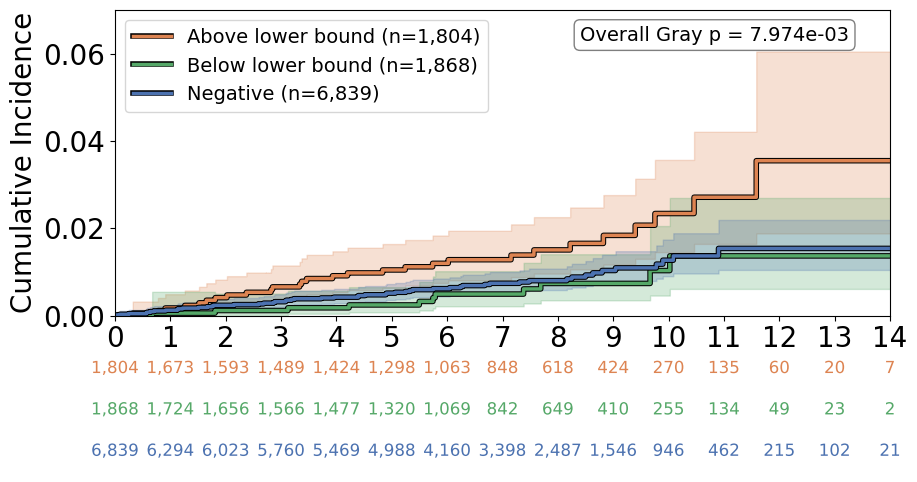

{'Above lower bound': {np.float64(1.0): 0.0017391850157276122,
  np.float64(5.0): 0.010457673612370566,
  np.float64(10.0): 0.023385466782371706,
  np.float64(12.0): 0.03548289633824081,
  np.float64(14.0): 0.03548289633824081},
 'Below lower bound': {np.float64(1.0): 0.0005702092025507089,
  np.float64(5.0): 0.0024445652299393042,
  np.float64(10.0): 0.010315359738532329,
  np.float64(12.0): 0.013677684060726898,
  np.float64(14.0): 0.013677684060726898},
 'Negative': {np.float64(1.0): 0.0012337551480536392,
  np.float64(5.0): 0.005148075969937095,
  np.float64(10.0): 0.01268888237271105,
  np.float64(12.0): 0.01539029625543482,
  np.float64(14.0): 0.01539029625543482}}

Age>=60
Gray test overall: 0.8362259862487005
Gray test pairwise: {('Above lower bound', 'Below lower bound'): 0.7975463096731104, ('Above lower bound', 'Negative'): 0.7626405639252026, ('Below lower bound', 'Negative'): 0.563320709457341}


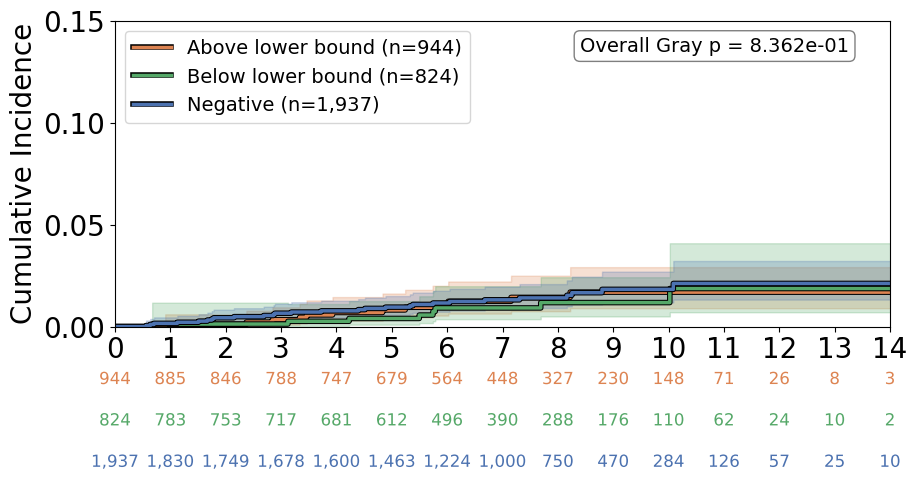

{'Above lower bound': {np.float64(1.0): 0.0010991517097227804,
  np.float64(5.0): 0.00818353609557515,
  np.float64(10.0): 0.01691752793457474,
  np.float64(12.0): 0.01691752793457474,
  np.float64(14.0): 0.01691752793457474},
 'Below lower bound': {np.float64(1.0): 0.001256456798923172,
  np.float64(5.0): 0.004001527328941175,
  np.float64(10.0): 0.011794830883479528,
  np.float64(12.0): 0.01869197993088838,
  np.float64(14.0): 0.01869197993088838},
 'Negative': {np.float64(1.0): 0.0016018613305511151,
  np.float64(5.0): 0.009559362564602394,
  np.float64(10.0): 0.018279405955114035,
  np.float64(12.0): 0.02119111432969466,
  np.float64(14.0): 0.02119111432969466}}

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
import numpy as np
import statsmodels.api as sm
from itertools import combinations
from scipy.stats import chi2_contingency, fisher_exact
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from tableone import TableOne
import re
import warnings 
warnings.filterwarnings('ignore')


df = pd.read_csv('../data/MGB_ms.csv', sep=",")

colors = sns.color_palette("deep", n_colors=10)
palette = {
    'MGUS' : colors[3],
    'Above lower bound' : colors[1],  
    'Below lower bound' : colors[2],  
    'Negative' : colors[0],
}


df_prog = df.copy()

df_prog['Ghobrial_Lab_Diagnosis_v3_simple'] = df_prog['Ghobrial_Lab_Diagnosis_v3_simple'].replace({
    'MGIP': 'Above lower bound',
    'Low peak': 'Below lower bound'
})

analysis_col = [
    ('event_MGUS', 'duration_MGUS_years'),
]

for event_col, duration_col in analysis_col:
    print(event_col)

    df_analysis = df_prog.dropna(subset=[duration_col, event_col]).copy()

    if event_col == 'event_MGUS':
        ########### Remove those negative progression date
        df_analysis = df_analysis[~(df_analysis['Prog_days_MGUS'] < 0)]
  
    ######### status (censored, progression, death)
    conditions = [
        (df_analysis[event_col] == 1),          # progression
        (df_analysis['Mortality'] == 'Yes'),    # death (competing)
        (df_analysis['Mortality'] == 'No')      # alive or no event
    ]
    
    choices = [1, 2, 0]   # 1=progression, 2=death, 0=censored
        
    df_analysis['status'] = np.select(conditions, choices, default=0)
         
    ###### MS diagnosis effect
    sex_to_include = ['F', 'M']
    race_to_include = ['White', 'Black', 'Asian', 'Hispanic', 'Other']
    fh_to_include = ['Yes', 'No']
    #diag_to_include = ['Negative', 'MGIP_Low', 'MGIP_High']
    #diag_to_include = ['Negative', 'MGIP']
    #diag_to_include = ['Negative', 'MGIP', 'MGUS']
    diag_to_include = ['Negative', 'Below lower bound', 'Above lower bound']

    group_col = 'Ghobrial_Lab_Diagnosis_v3_simple'
    
    cox_df_v2 = df_analysis[
        #(df_analysis['Sex'].isin(sex_to_include)) &
        #(df_analysis['Race_v2'].isin(race_to_include)) &
        #(df_analysis['hema_fh'].isin(fh_to_include)) &
        (df_analysis[group_col].isin(diag_to_include)) #Ghobrial_Lab_Diagnosis_v3_simple
    ]

    ## Race
    cox_df_v2['Race_binary'] = np.where(cox_df_v2['Race_v2'] != 'Black', 'non-Black', 'Black')

        
    cox_df_v2 = cox_df_v2.dropna(subset=[event_col, duration_col, "status"])
    cox_df_v2 = cox_df_v2[cox_df_v2[duration_col] >=0]
    
    print(f'Data used (N) for MGUS progression (Low peak, MGIP and Negative) = {len(cox_df_v2):,}')   

    ######### Numbers ###########
    diag_col = 'Ghobrial_Lab_Diagnosis_v3_simple' 

    print(cox_df_v2[diag_col].value_counts())
    
    summary = cox_df_v2.groupby([diag_col, 'major_type']).agg({
        'Conc_1': ['min', 'max', 'count'], 
        event_col: ['sum']                 
    })
    
    summary.columns = ['Conc_Min', 'Conc_Max', 'Total_N', 'Event_Count']
    
    summary['Event_Rate(%)'] = (summary['Event_Count'] / summary['Total_N'] * 100).round(1)
    
    display(summary)

    ### how many <0.2g/L
    for ig_type in ['IgG', 'IgA', 'IgM']:
        igg_high = cox_df_v2[
            (cox_df_v2[diag_col] == 'Above lower bound') &  
            (cox_df_v2['major_type'] == ig_type)
        ].copy()
        
        igg_high['Conc_Group'] = igg_high['Conc_1'].apply(
            lambda x: f'{ig_type} Above lower bound (< 0.2)' if x < 0.2 else f'{ig_type} Above lower bound (>= 0.2)'
        )
        
        igg_summary = igg_high.groupby('Conc_Group').agg({
            'Conc_1': ['min', 'max', 'count'],
            event_col: ['sum']
        })
        
        igg_summary.columns = ['Conc_Min', 'Conc_Max', 'Total_N', 'Event_Count']
        igg_summary['Event_Rate(%)'] = (igg_summary['Event_Count'] / igg_summary['Total_N'] * 100).round(1)
        
        display(igg_summary)


    ######### CUMULATIVE INCIDENCE FUNCTION
    res = plot_cif_aj_with_graytest(
        cox_df_v2, duration_col, "status", group_col,
        event_of_interest=1,
        group_order=diag_to_include[::-1],
        palette=palette,
        ylim=(0, 0.07),
        figsize=(10,6),
        do_gray_test=True,
        time_points=np.arange(0, 15, 1),
        overall_pval=True,
        return_cif_at=[1, 5, 10, 12, 14],
        save='../00.Figures/MGB_total_cumulative_MGUS_progression.pdf',
    )

    display(res['cif_at_times'])
    
    #age_cox_df_v2 = cox_df_v2[(cox_df_v2['Age'] >= 60) & (cox_df_v2['Age'] < 70)]
    #for age_lim in [50, 55, 60, 65]:
    for age in [60]:
        for mode in ['>=', '<']:
            if mode == "<":
                cut_cox_df_v2 = cox_df_v2[cox_df_v2['Age'] < age]
            else:
                cut_cox_df_v2 = cox_df_v2[cox_df_v2['Age'] >= age]
            mode_age = mode+str(age)
            print(f'Age{mode_age}')
            res2 = plot_cif_aj_with_graytest(
                cut_cox_df_v2, duration_col, "status", group_col,
                event_of_interest=1,
                group_order=diag_to_include[::-1],
                palette=palette,
                ylim=(0, 0.15),
                figsize=(10,6),
                do_gray_test=True,
                overall_pval=True,
                return_cif_at=[1, 5, 10, 12, 14],
                save=f'../00.Figures/MGB_total_cumulative_MGUS_progression_{mode_age}.pdf'
            )

            display(res2['cif_at_times'])

